In [12]:
%pip install py3Dmol MDAnalysis nglview matplotlib MDAnalysisTests
import py3Dmol
import MDAnalysis as mda
from MDAnalysisTests.datafiles import PSF, DCD
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt

  Using cached nglview-4.0.1-py3-none-any.whl
  Using cached notebook-7.5.5-py3-none-any.whl.metadata (10 kB)
  Using cached jupyterlab-4.5.6-py3-none-any.whl.metadata (16 kB)
Using cached notebook-7.5.5-py3-none-any.whl (14.6 MB)
Using cached jupyterlab-4.5.6-py3-none-any.whl (12.4 MB)

  Attempting uninstall: jupyterlab

    Found existing installation: jupyterlab 4.5.5

   ---------------------------------------- 0/3 [jupyterlab]
    Uninstalling jupyterlab-4.5.5:
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupyterlab]
      Successfully uninstalled jupyterlab-4.5.5
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupyterlab]
   ---------------------------------------- 0/3 [jupy

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\benmm\\AppData\\Local\\Python\\pythoncore-3.14-64\\Scripts\\jupyter-lab.exe' -> 'C:\\Users\\benmm\\AppData\\Local\\Python\\pythoncore-3.14-64\\Scripts\\jupyter-lab.exe.deleteme'
Consider using the `--user` option or check the permissions.



In [13]:
view = py3Dmol.view(query='pdb:1HVR')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [14]:
view = py3Dmol.view(query='pdb:1HVR')
view.setStyle({'cartoon': {'color': 'spectrum'}})
view.addStyle({'hetflag': True}, {'stick': {}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

C:\Users\benmm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\MDAnalysis\coordinates\DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


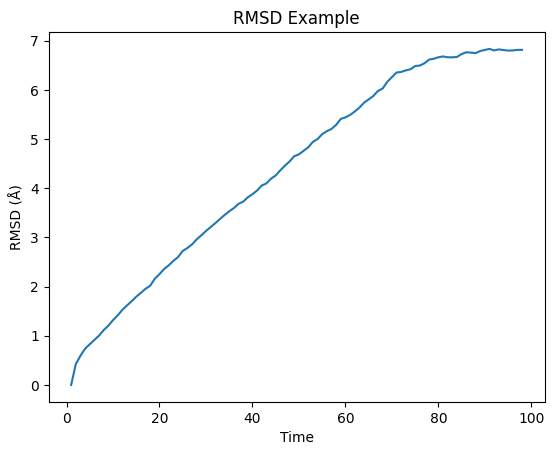

In [15]:
#example trajectory
#load a sample molecular dynamics system (topology + trajectory)
#PSF is topology file(atoms, bonds)
#DCD is = trajectory file
u = mda.Universe(PSF, DCD)


# Create an RMSD analysis object
# - u (first argument) the trajectory being analyzed
# - u (second argument): is the refrence structure which is the same system
# - select="protein and name CA" because thi9s is the backbone and it limits outside noise from 
#   -> reduces noise and tracks overall protein backbone movement
# - ref_frame=0: use the first frame of the trajectory as the reference
R = rms.RMSD(u, u, select="protein and name CA", ref_frame=0)
R.run()

rmsd_data = R.results.rmsd

# Extract the computed RMSD results
# The output is a NumPy array with columns:
# [frame index, time (ps), RMSD (Å)]
plt.plot(rmsd_data[:,1], rmsd_data[:,2])
plt.xlabel("Time")
plt.ylabel("RMSD (Å)")
plt.title("RMSD Example")
plt.show()

In [16]:
print(PSF)
print(DCD)

C:/Users/benmm/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/MDAnalysisTests/data/adk.psf
C:/Users/benmm/AppData/Local/Python/pythoncore-3.14-64/Lib/site-packages/MDAnalysisTests/data/adk_dims.dcd


In [17]:
# TEST COMMIT